# Parte III — *Learning Vector Quantization* (LVQ)

### Clasificación supervisada basada en prototipos

> **Estructura de la sección.** Se aborda sucesivamente la descripción del algoritmo, la publicación que lo propuso, el tipo de modelo, el algoritmo de entrenamiento, los tipos de entrada, los casos de uso, los supuestos y restricciones, la implementación en Python y las conclusiones. Las referencias bibliográficas se proporcionan en formato BibTeX y APA.

## 1. Descripción del algoritmo

**Learning Vector Quantization (LVQ)**, propuesto por Teuvo Kohonen, es un algoritmo de **clasificación supervisada basado en prototipos**. Un prototipo es un vector del espacio de características que actúa como representante de una clase o de una región de ésta.

El entrenamiento se rige por una **regla de aprendizaje competitivo**: para cada muestra se identifica el prototipo más cercano —la *best matching unit*— y se ajusta su posición según el acierto de la clasificación. Si el prototipo ganador pertenece a la clase correcta, se desplaza hacia la muestra; si pertenece a una clase distinta, se aleja de ella. Tras varias épocas, los prototipos convergen hacia configuraciones que delimitan las fronteras de decisión entre clases.

La clasificación de una nueva observación se resuelve asignándole la clase del prototipo más próximo. Por este motivo, LVQ guarda una estrecha relación conceptual con el clasificador del **vecino más cercano** *(Nearest Neighbor)* y con las **redes competitivas de Kohonen**, de las que constituye la contraparte supervisada.

## 2. Publicación que propuso el algoritmo

### BibTeX — LVQ
```bibtex
@article{kohonen1988learning,
  title   = {Learning Vector Quantization},
  author  = {Kohonen, Teuvo},
  journal = {Neural Networks},
  volume  = {1},
  pages   = {303},
  year    = {1988}
}
```

### BibTeX — Monografía de referencia
```bibtex
@book{kohonen1995self,
  title     = {Self-Organizing Maps},
  author    = {Kohonen, Teuvo},
  year      = {1995},
  publisher = {Springer},
  address   = {Berlin}
}
```

### Referencias APA
- Kohonen, T. (1988). *Learning Vector Quantization*. Neural Networks, 1, 303.
- Kohonen, T. (1995). *Self-Organizing Maps*. Springer.

## 3. Tipo de modelo

| Dimensión | Clasificación para LVQ |
|---|---|
| **Método de aprendizaje** | Supervisado |
| **Tipo de problema** | Clasificación |
| **Por parámetros** | No paramétrico / basado en prototipos |
| **Datos al entrenar** | Online / incremental, aunque puede entrenarse por épocas sobre un dataset |
| **Resultado del entrenamiento** | Basado en instancias/prototipos |
| **Familia de algoritmos** | Instance-based / Prototype-based learning |

## 4. Algoritmo de entrenamiento

Sea $x$ una muestra de entrenamiento y $w_j$ el prototipo más cercano.

### Distancia euclidiana
$$
BMU = \arg\min_j ||x - w_j||
$$

### Actualización LVQ1
Si el prototipo ganador pertenece a la clase correcta:

$$
w_j(t+1) = w_j(t) + \alpha(t)(x - w_j(t))
$$

Si pertenece a una clase incorrecta:

$$
w_j(t+1) = w_j(t) - \alpha(t)(x - w_j(t))
$$

Donde $\alpha(t)$ es la tasa de aprendizaje, que normalmente decrece con las épocas.

### Proceso general
1. Inicializar prototipos por clase.
2. Para cada muestra, encontrar el prototipo más cercano.
3. Acercar o alejar el prototipo según si clasifica correctamente.
4. Repetir durante varias épocas.
5. Clasificar nuevas muestras por el prototipo más cercano.

## 5. Tipos de entrada

- Vectores numéricos.
- Etiquetas de clase conocidas.
- Datos escalados o normalizados, porque LVQ depende de distancias.
- Variables categóricas deben codificarse antes de entrenar.

## 6. Casos de uso

| Área | Ejemplo |
|---|---|
| Reconocimiento de patrones | Clasificación de señales o formas |
| Visión computacional | Clasificación de imágenes mediante vectores de características |
| Medicina | Clasificación de pacientes según mediciones clínicas |
| Audio / sensores | Clasificación de señales o eventos |
| Industria | Clasificación de estados de máquina o fallas |
| Bioinformática | Clasificación de muestras biológicas |

## 7. Supuestos y restricciones

### Supuestos
- Las clases pueden representarse mediante prototipos en el espacio de características.
- La métrica de distancia usada es adecuada para el problema.
- Los datos están correctamente escalados.

### Restricciones
- Es sensible a la escala de las variables.
- Es sensible a la inicialización y al número de prototipos.
- Puede fallar si las clases se solapan demasiado.
- Requiere elegir tasa de aprendizaje, número de épocas y prototipos por clase.

## 8. Source code — implementación LVQ1 desde cero

El siguiente código implementa **LVQ1** y lo aplica al dataset Iris.

In [ ]:
# ============================================================
# Instalación opcional para Colab / Anaconda
# ============================================================
# !pip install numpy pandas scikit-learn matplotlib

In [17]:
# ============================================================
# PASO 1: Importar librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print('Librerías importadas correctamente')

Librerías importadas correctamente


In [18]:
# ============================================================
# PASO 2: Implementar LVQ1
# ============================================================
class LVQ1Classifier:
    # Implementación didáctica de Learning Vector Quantization 1.

    def __init__(self, prototypes_per_class=2, learning_rate=0.05, epochs=100,
                 decay=True, random_state=42):
        self.prototypes_per_class = prototypes_per_class
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.decay = decay
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        rng = np.random.default_rng(self.random_state)

        self.classes_ = np.unique(y)
        prototypes = []
        prototype_labels = []

        # Inicializar prototipos eligiendo muestras reales de cada clase
        for cls in self.classes_:
            X_cls = X[y == cls]
            replace = len(X_cls) < self.prototypes_per_class
            idx = rng.choice(len(X_cls), size=self.prototypes_per_class, replace=replace)
            prototypes.append(X_cls[idx])
            prototype_labels.extend([cls] * self.prototypes_per_class)

        self.prototypes_ = np.vstack(prototypes).astype(float)
        self.prototype_labels_ = np.array(prototype_labels)

        # Entrenamiento competitivo
        for epoch in range(self.epochs):
            if self.decay:
                lr = self.learning_rate * (1.0 - epoch / max(1, self.epochs))
            else:
                lr = self.learning_rate

            for i in rng.permutation(len(X)):
                distances = np.linalg.norm(self.prototypes_ - X[i], axis=1)
                winner = np.argmin(distances)

                if self.prototype_labels_[winner] == y[i]:
                    self.prototypes_[winner] += lr * (X[i] - self.prototypes_[winner])
                else:
                    self.prototypes_[winner] -= lr * (X[i] - self.prototypes_[winner])

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        distances = np.linalg.norm(X[:, None, :] - self.prototypes_[None, :, :], axis=2)
        winners = np.argmin(distances, axis=1)
        return self.prototype_labels_[winners]

In [19]:
# ============================================================
# PASO 3: Cargar dataset Iris
# ============================================================
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print('Shape:', X.shape)
print('Clases:', iris.target_names)
X.head()

Shape: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [20]:
# ============================================================
# PASO 4: División Train / Test y escalado
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape[0]} muestras')
print(f'Test:  {X_test_scaled.shape[0]} muestras')

Train: 105 muestras
Test:  45 muestras


In [21]:
# ============================================================
# PASO 5: Entrenar LVQ
# ============================================================
lvq = LVQ1Classifier(
    prototypes_per_class=2,
    learning_rate=0.08,
    epochs=120,
    decay=True,
    random_state=42
)

lvq.fit(X_train_scaled, y_train)
print('Modelo LVQ entrenado con éxito')
print('Número de prototipos:', len(lvq.prototypes_))

Modelo LVQ entrenado con éxito
Número de prototipos: 6


In [22]:
# ============================================================
# PASO 6: Evaluación del modelo
# ============================================================
y_pred = lvq.predict(X_test_scaled)

print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 95.56 %

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      1.00      0.94        15
   virginica       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



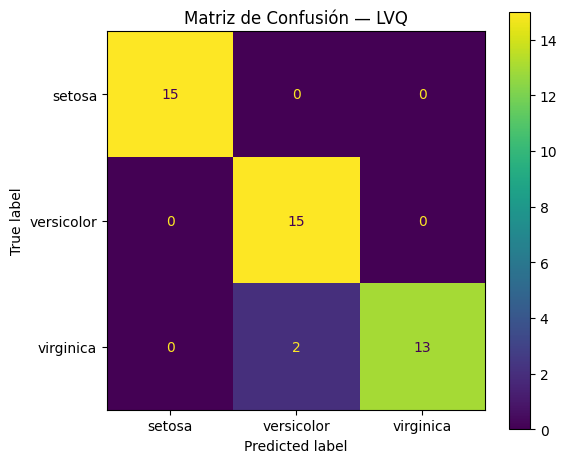

In [23]:
# ============================================================
# PASO 7: Matriz de confusión
# ============================================================
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=ax, values_format='d')
plt.title('Matriz de Confusión — LVQ')
plt.tight_layout()
plt.show()

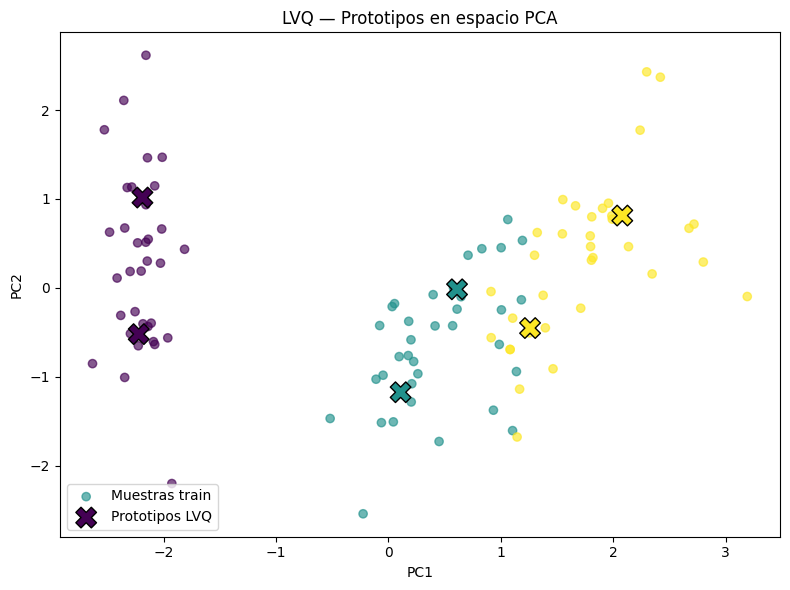

In [24]:
# ============================================================
# PASO 8: Visualización PCA de muestras y prototipos
# ============================================================
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
prototypes_2d = pca.transform(lvq.prototypes_)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, alpha=0.65, label='Muestras train')
plt.scatter(prototypes_2d[:, 0], prototypes_2d[:, 1], c=lvq.prototype_labels_, marker='X', s=220, edgecolors='black', label='Prototipos LVQ')
plt.title('LVQ — Prototipos en espacio PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# PASO 9: Predicción de una nueva muestra
# ============================================================
new_sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=iris.feature_names)
new_sample_scaled = scaler.transform(new_sample)
new_prediction = lvq.predict(new_sample_scaled)[0]

print('Nueva muestra:')
display(new_sample)
print('Predicción LVQ:', iris.target_names[new_prediction])

Nueva muestra:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2


Predicción LVQ: setosa


## 9. Conclusión

La implementación de LVQ1 alcanzó una exactitud del 95.56 % sobre el conjunto de prueba del dataset *Iris*, con un único par de muestras *versicolor*–*virginica* confundidas, lo que concuerda con el solapamiento conocido entre ambas clases. La proyección PCA evidencia, además, cómo los prototipos se ubican en posiciones representativas de cada clase tras el entrenamiento competitivo.

La fortaleza distintiva de LVQ radica en que **condensa el conjunto de entrenamiento en un número reducido de vectores prototípicos interpretables**, lo que reduce el coste de almacenamiento y de inferencia respecto a los métodos perezosos como *k*-NN. Sus principales limitaciones son la **sensibilidad al escalado de las variables**, a la inicialización de los prototipos y a la elección de los hiperparámetros —tasa de aprendizaje, número de épocas y prototipos por clase—, aspectos que deben calibrarse cuidadosamente para garantizar un buen desempeño.